# Topic: ARIMA & SARIMA Pattern

## Definition (30-second explanation)
*   **ARIMA (AutoRegressive Integrated Moving Average):** A classic statistical time series model that captures trends and autocorrelations by combining past values (AR), differencing for stationarity (I), and past forecast errors (MA).
*   **SARIMA (Seasonal ARIMA):** An extension of ARIMA that explicitly supports univariate time series data with a seasonal component by adding seasonal AR, I, MA, and length of season parameters (P, D, Q, m).

## Why Interviewers Ask This
*   To test your foundational understanding of time series forecasting before jumping to complex neural networks.
*   To evaluate your knowledge of statistical assumptions (like stationarity) and diagnostics (residuals).
*   To see if you know how to balance model complexity (overfitting) using information criteria like AIC/BIC.

## Core Concepts
*   **AR (p):** Uses past values to predict current values (lags). Found via PACF plots.
*   **I (d):** Differencing to make the series stationary. Determined using the ADF (Augmented Dickey-Fuller) test.
*   **MA (q):** Uses past forecast errors to predict current values. Found via ACF plots.
*   **Seasonal Elements (P, D, Q, m):** Analogous to p, d, q but applied to the seasonal lags (e.g., $m=12$ for monthly data with annual seasonality).

## When to Use
*   Use ARIMA for non-seasonal, univariate time series data showing clear trend or autocorrelations.
*   Use SARIMA for univariate time series data exhibiting repeating seasonal patterns (e.g., retail sales peaking every December).
*   Best suited for short-to-medium term forecasting where historical patterns are expected to continue.

## Advantages
*   Highly interpretable; you can explicitly see the impact of past lags and errors.
*   `auto_arima` automates the complex parameter selection (p, d, q) process using AIC minimization.
*   Requires relatively little data compared to Deep Learning models like LSTMs.

## Limitations
*   Cannot easily handle multiple seasonalities (e.g., daily and yearly simultaneously) or complex holiday effects (where Prophet excels).
*   Assumes a linear relationship between past and future values.
*   Uncertainty grows rapidly when forecasting too far into the future.

## Common Comparisons
*   **ARIMA vs. SARIMA:** SARIMA includes seasonal terms (P, D, Q, m) whereas ARIMA assumes no repeating seasonal cycles.
*   **SARIMA vs. Prophet:** Prophet is better for business data with multiple seasonalities, missing data, and holiday impacts.
*   **ARIMA vs. LSTM:** LSTM handles non-linear patterns but requires significantly more data and lacks statistical interpretability.

## Common Interview Traps
*   **Forgetting Residual Analysis:** Not checking if residuals look like white noise (which indicates the model captured all signals).
*   **Ignoring Stationarity:** Applying ARIMA without checking for stationarity via ADF test or failing to difference the data properly.
*   **Overfitting:** Adding too many AR/MA terms blindly without checking if AIC/BIC actually improves.
*   **Misapplying Models:** Using standard ARIMA on highly seasonal data instead of SARIMA.

## Python Syntax
```python
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# 1. Auto ARIMA to find best parameters
auto_model = auto_arima(train, start_p=0, start_q=0, max_p=5, max_q=5, 
                        d=None, seasonal=True, m=12, # set seasonal=True and m for SARIMA
                        stepwise=True, information_criterion='aic')

print(f"Best order: {auto_model.order}")
print(f"Best seasonal order: {auto_model.seasonal_order}")

# 2. Fit final model (using standard ARIMA as example)
model = ARIMA(train, order=auto_model.order)
fitted = model.fit()

# 3. Forecast
forecast = fitted.forecast(steps=len(test))
```

## Important Formula:

- ARIMA(p, d, q) Equation:

$$y_t = c + \phi_1 y_{t-1} + ... + \phi_p y_{t-p} + \theta_1 e_{t-1} + ... + \theta_q e_{t-q} + e_t$$
(Where $\phi$ are AR coefficients, $\theta$ are MA coefficients, and $e_t$ is white noise)

## 45-Second Interview Answer
"ARIMA is a foundational statistical model for time series forecasting that combines AutoRegressive lags, Integration (differencing) for stationarity, and Moving Average error terms. We determine its parameters (p, d, q) using ACF/PACF plots or automated AIC optimization. If the data has seasonal cycles, I upgrade to SARIMA by adding seasonal P, D, Q, and frequency parameters. While robust and interpretable for linear trends, if the business problem involves complex holidays or multiple seasonalities, I typically pivot to tools like Facebook Prophet."

## Practice Questions:

### Q1: What does the 'I' in ARIMA stand for and why is it important?

**Answer:**
The 'I' stands for Integrated. It represents the differencing step applied to the time series data to make it stationary. Stationarity (constant mean and variance over time) is a core assumption for AR and MA models. By subtracting the previous observation from the current one ($d$ times), we remove trends, allowing the AR and MA components to model the underlying signal effectively.

**Common mistakes candidates make:**
*   Forgetting to mention that its primary purpose is achieving *stationarity*.
*   Confusing differencing with normalization or scaling.

**One likely interviewer follow-up:**
How do you mathematically determine the optimal value for 'd'? 
*(Answer: By using statistical tests like the Augmented Dickey-Fuller (ADF) test; we keep differencing until the p-value falls below 0.05.)*

### Q2. How do you use ACF and PACF plots to select p and q?

**Answer:**
After making the series stationary, I look at the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots. 
*   To find $p$ (AR terms), I look at the PACF plot. The lag where the PACF cuts off (drops to zero/within the confidence interval) indicates $p$. 
*   To find $q$ (MA terms), I look at the ACF plot. The lag where the ACF cuts off indicates $q$. 
If both taper off gradually, it's a mixed ARIMA model, and I'd rely on grid search via `auto_arima` minimizing the AIC.

**Common mistakes candidates make:**
*   Mixing up which plot corresponds to which parameter (ACF -> MA/q, PACF -> AR/p).
*   Not explicitly stating that the data must be stationary *before* interpreting these plots.

**One likely interviewer follow-up:**
What does the PACF represent that the ACF does not?
*(Answer: PACF isolates the direct effect of a specific past lag on the current value by removing the indirect effects of the intermediate lags.)*

### Q3. When would you use SARIMA instead of ARIMA?

**Answer:**
I would use SARIMA when the time series exhibits clear, repeating seasonal patterns, such as retail sales spiking every December or airline passengers peaking in summer. Standard ARIMA only captures sequential dependencies, whereas SARIMA adds seasonal autoregressive, differencing, and moving average terms (P, D, Q) along with a frequency parameter ($m$) to model lags spanning exactly one seasonal cycle.

**Common mistakes candidates make:**
*   Using standard ARIMA on seasonal data and wondering why the forecasts are flat or poor.
*   Forgetting the $m$ (seasonality length) parameter when explaining SARIMA.

**One likely interviewer follow-up:**
If your data has daily seasonality and yearly seasonality, would you still use SARIMA?
*(Answer: Probably not. SARIMA struggles with multiple seasonalities. I would switch to Facebook Prophet or TBATS, which handle complex, overlapping seasonalities much better.)*

### Q4. What is the ADF test and what does it tell you?

**Answer:**
The Augmented Dickey-Fuller (ADF) test is a statistical hypothesis test used to check for stationarity in a time series. The null hypothesis is that the series has a unit root (meaning it is non-stationary). If the resulting p-value is less than a threshold (typically 0.05), we reject the null hypothesis and conclude the time series is stationary.

**Common mistakes candidates make:**
*   Getting the null hypothesis backward (thinking H0 is that the series *is* stationary).
*   Failing to mention the p-value threshold used for decision-making.

**One likely interviewer follow-up:**
If the ADF test indicates the series is not stationary, what is your immediate next step?
*(Answer: Apply a first-order difference ($y_t - y_{t-1}$) and run the ADF test again on the differenced data.)*

### Q5. How would you forecast electricity demand for the next 30 days?

**Answer:**
First, I'd conduct EDA on historical electricity demand, looking for trends, daily/weekly/yearly seasonalities, and holiday impacts. Since electricity usually has complex, multiple seasonalities (e.g., peaking mid-day and peaking in summer) and responds to external regressors like temperature, standard SARIMA might be insufficient. I would set up a baseline model using Prophet or a SARIMAX model incorporating weather forecasts as exogenous variables. I would split my data chronologically, train the model, evaluate using MAPE and RMSE, verify that residuals look like white noise, and finally generate the 30-day forward forecast.

**Common mistakes candidates make:**
*   Suggesting a basic ARIMA model without acknowledging the complex seasonality of electricity.
*   Not mentioning exogenous variables (like weather/temperature) which are critical for energy forecasting.
*   Proposing random train/test splits instead of chronological splits.

**One likely interviewer follow-up:**
Why might RMSE be a better evaluation metric than MAE in this specific electricity forecasting scenario?
*(Answer: RMSE penalizes larger errors more heavily. In electricity forecasting, a massive under-prediction can lead to grid blackouts, so we want to penalize large deviations disproportionately.)*

### Q6. Scenario: Forecasting E-commerce Sales with Multiple Seasonalities and Exogenous Variables

**Question:**
You need to forecast daily sales for 90 days. The data has weekend spikes, a summer dip, and massive Black Friday spikes. You have `sales`, `marketing_spend`, and `is_holiday` columns. Would you use ARIMA, SARIMA, or something else? How would you use the extra columns?

**Answer:**
I would use Facebook Prophet (or a similar specialized model like TBATS or LightGBM) rather than SARIMA. SARIMA struggles with daily data that exhibits multiple overlapping seasonalities (like weekly weekend spikes plus yearly summer dips). Prophet is explicitly designed to handle multiple seasonalities out-of-the-box. 

To incorporate the extra columns:
1.  **Holidays:** Prophet has built-in holiday effects where I can pass the `is_holiday` column (or a custom dataframe for Black Friday) to model the massive spikes separately from regular seasonality.
2.  **Marketing Spend:** I would add `marketing_spend` as an additional exogenous regressor (using Prophet's `add_regressor` feature). 
If I were to use a statistical baseline, I would use SARIMAX, treating both `marketing_spend` and `is_holiday` as exogenous 'X' variables, though it would still struggle with the dual seasonality.

**Common mistakes candidates make:**
*   Suggesting SARIMA without realizing it only natively supports one seasonal period (e.g., just $m=7$ OR $m=365$, but not both easily).
*   Forgetting to explain *how* exogenous variables (like marketing spend) are actually fed into the chosen model.

**One likely interviewer follow-up:**
Because time series data is sequential, how would you evaluate this Prophet model to ensure it doesn't overfit?
*(Answer: I cannot use standard k-fold cross-validation because it leaks future data into the past. I must use Time Series Cross-Validation, such as a rolling window or expanding window approach, where the training set only consists of data prior to the validation window.)*

### Q7: Coding Challenge 1: ARIMA / SARIMA Pipeline

**Question:** Write a clean Python script to split time series data, check stationarity, find optimal seasonal ARIMA parameters automatically, fit the model, forecast 12 periods, and evaluate using RMSE and MAPE.

In [29]:
# Data:
import numpy as np
import pandas as pd

# Generate reproducible monthly data with trend and annual seasonality (m=12)
np.random.seed(42)
dates = pd.date_range(start='2018-01-01', periods=72, freq='MS') # 6 years of monthly data
trend = np.linspace(50, 150, 72)
seasonality = 20 * np.sin(2 * np.pi * np.arange(72) / 12)
noise = np.random.normal(0, 5, 72)
sales = trend + seasonality + noise

df = pd.DataFrame({'date': dates, 'sales': sales})
df.set_index('date', inplace=True)

In [30]:
df

,sales
date,
2018-01-01,52.483571
2018-02-01,60.717129
2018-03-01,73.375852
2018-04-01,81.840501
2018-05-01,71.783544
...,...
2023-08-01,139.383862
2023-09-01,130.262320
2023-10-01,123.957500


In [31]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Chronological Split (NEVER shuffle time series)
# Using index slicing is safest for explicit horizon lengths
train = df.iloc[:-12]
test = df.iloc[-12:]

# 2. Stationarity Check
p_value = adfuller(train['sales'])[1]
print(f"Stationary: {p_value < 0.05} (p-value: {p_value:.3f})")

# 3. Auto ARIMA (finds parameters and fits simultaneously)
# d=None allows automatic detection of required differencing
model = auto_arima(train['sales'], 
                   seasonal=True, m=12, 
                   d=None, D=None, 
                   stepwise=True, trace=False)
print(f"Optimal SARIMA Order: {model.order}, Seasonal: {model.seasonal_order}")

# 4. Forecast Out-of-Sample
preds = model.predict(n_periods=len(test))

# 5. Evaluate
rmse = np.sqrt(mean_squared_error(test['sales'], preds))
mape = mean_absolute_percentage_error(test['sales'], preds)
print(f"RMSE: {rmse:.2f} | MAPE: {mape:.2f}")

Stationary: False (p-value: 0.996)
Optimal SARIMA Order: (1, 1, 1), Seasonal: (1, 0, 1, 12)
RMSE: 4.72 | MAPE: 0.03


**Interview Tips:**
- Always point out why you didn't shuffle the train/test split.
- Mention that auto_arima minimizes the AIC (Akaike Information Criterion) to select the best parameters.

#### Option 2: Two-Step Pipeline (pmdarima for search -> statsmodels for fitting)

**Note:** This is the pattern often expected when interviewers want to see you explicitly use the `statsmodels` library for the final modeling, using `pmdarima` strictly as a grid-search helper.

In [32]:
# 1. Imports Grouped at Top
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# 2. Chronological Train-Test Split 
# shuffle=False is critical to prevent data leakage in time series
X_train, X_test = train_test_split(df, train_size=0.84, shuffle=False)

# 3. Check Stationarity on the target series explicitly
p_value = adfuller(X_train['sales'])[1]
if p_value < 0.05:
    print('Training Data is Stationary.')
else:
    print('Training Data is Not Stationary.')

# 4. Grid Search for Optimal Parameters using pmdarima
# Setting d=None allows the algorithm to detect if differencing is needed automatically
autoArima = auto_arima(
    y=X_train['sales'], 
    start_p=0, d=None, start_q=0, 
    start_P=0, start_Q=0, 
    max_p=5, max_q=5, max_P=5, max_Q=5,
    seasonal=True, m=12,
    trace=False # Set to True in practice to see the search logs
)

print(f"Chosen Order: {autoArima.order}")
print(f"Chosen Seasonal Order: {autoArima.seasonal_order}")

# 5. Fit the Final Model using statsmodels SARIMAX
model = SARIMAX(
    X_train['sales'], 
    order=autoArima.order, 
    seasonal_order=autoArima.seasonal_order
)
fitted_model = model.fit(disp=False)

# 6. Forecast Out-of-Sample
# 12 months horizon
preds = fitted_model.forecast(12).values

# 7. Evaluate Performance
rmse = np.round(np.sqrt(mean_squared_error(X_test['sales'], preds)), 2)
mape = np.round(mean_absolute_percentage_error(X_test['sales'], preds), 2)

print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')

Training Data is Not Stationary.
Chosen Order: (0, 1, 1)
Chosen Seasonal Order: (4, 0, 0, 12)


/home/shail/interview-prep/interview_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


RMSE: 4.87
MAPE: 0.03


### Q8: Coding Challenge 2: Prophet with Regressors & Time Series CV

**Scenario:** You have daily data with `ds`, `y` (sales), and `marketing_spend`. Build a Prophet model, forecast 30 days, and demonstrate Time Series Cross-Validation to prevent data leakage.

In [77]:
# Data:
import pandas as pd
import numpy as np

np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')
# Baseline sales + weekly seasonality + marketing impact + noise
sales = 500 + (200 * np.sin(2 * np.pi * np.arange(365) / 7)) 
marketing_spend = np.random.randint(100, 1000, 365)
sales += marketing_spend * 0.5 
sales += np.random.normal(0, 50, 365)

df = pd.DataFrame({'ds': dates, 'y': sales, 'marketing_spend': marketing_spend})

In [78]:
df

,ds,y,marketing_spend
0,2023-01-01,615.653624,202
1,2023-01-02,888.148726,535
2,2023-01-03,1268.274308,960
3,2023-01-04,795.468394,370
4,2023-01-05,456.658077,206
...,...,...,...
360,2023-12-27,659.438181,203
361,2023-12-28,926.492813,951
362,2023-12-29,506.560277,353
363,2023-12-30,457.755941,326


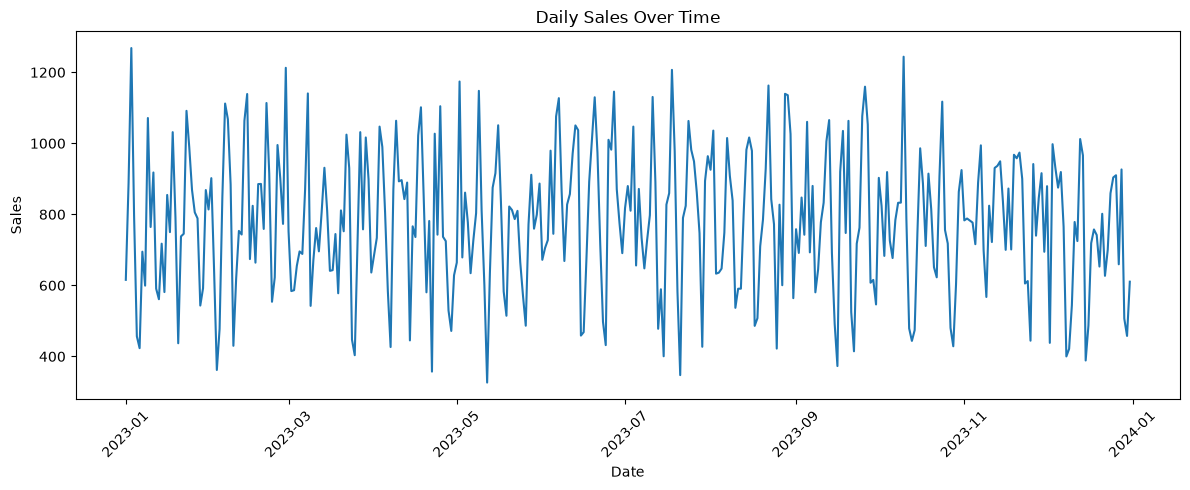

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df['ds'], df['y'])

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Daily Sales Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit

# 1. Split Data (Chronological)
train = df.iloc[:-30]
test = df.iloc[-30:]

# 2. Fit Prophet with Regressor
m = Prophet()
m.add_regressor('marketing_spend') # MUST be added before fit()
m.fit(train)

# 3. Predict Future
# Since we have an exogenous variable, we pass the test set directly 
# because it contains both future 'ds' and future 'marketing_spend'.
forecast = m.predict(test)

05:14:01 - cmdstanpy - INFO - Chain [1] start processing
05:14:01 - cmdstanpy - INFO - Chain [1] done processing


In [81]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,marketing_spend,marketing_spend_lower,marketing_spend_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-12-02,780.028621,313.666129,442.256122,780.028621,780.028621,-398.690937,-398.690937,-398.690937,-238.233700,...,-238.233700,-238.233700,-238.233700,-160.457237,-160.457237,-160.457237,0.0,0.0,0.0,381.337684
1,2023-12-03,779.993193,938.586857,1069.920003,779.993193,779.993193,225.657827,225.657827,225.657827,219.212659,...,219.212659,219.212659,219.212659,6.445168,6.445168,6.445168,0.0,0.0,0.0,1005.651020
2,2023-12-04,779.957766,787.680508,917.338826,779.957758,779.957766,74.246971,74.246971,74.246971,-83.877499,...,-83.877499,-83.877499,-83.877499,158.124470,158.124470,158.124470,0.0,0.0,0.0,854.204737
3,2023-12-05,779.922338,802.446499,930.295363,779.922305,779.922355,82.067097,82.067097,82.067097,-109.433161,...,-109.433161,-109.433161,-109.433161,191.500258,191.500258,191.500258,0.0,0.0,0.0,861.989435
4,2023-12-06,779.886910,897.408636,1022.741040,779.886853,779.886966,179.094375,179.094375,179.094375,93.989912,...,93.989912,93.989912,93.989912,85.104462,85.104462,85.104462,0.0,0.0,0.0,958.981285
5,2023-12-07,779.851482,615.174751,745.623656,779.851383,779.851579,-99.724649,-99.724649,-99.724649,-7.721624,...,-7.721624,-7.721624,-7.721624,-92.003025,-92.003025,-92.003025,0.0,0.0,0.0,680.126833
6,2023-12-08,779.816055,309.007485,434.843812,779.815896,779.816193,-409.058833,-409.058833,-409.058833,-220.344736,...,-220.344736,-220.344736,-220.344736,-188.714096,-188.714096,-188.714096,0.0,0.0,0.0,370.757222
7,2023-12-09,779.780627,398.780831,525.164971,779.780399,779.780825,-317.935043,-317.935043,-317.935043,-157.477807,...,-157.477807,-157.477807,-157.477807,-160.457237,-160.457237,-160.457237,0.0,0.0,0.0,461.845583
8,2023-12-10,779.745199,487.170980,616.631021,779.744894,779.745448,-228.210740,-228.210740,-228.210740,-234.655907,...,-234.655907,-234.655907,-234.655907,6.445168,6.445168,6.445168,0.0,0.0,0.0,551.534459
9,2023-12-11,779.709771,752.029007,884.225787,779.709380,779.710107,37.957930,37.957930,37.957930,-120.166539,...,-120.166539,-120.166539,-120.166539,158.124470,158.124470,158.124470,0.0,0.0,0.0,817.667702


In [82]:
# 4. Time Series Cross-Validation (Expanding Window)
tscv = TimeSeriesSplit(n_splits=3)
for train_index, val_index in tscv.split(train):
    train_fold = train.iloc[train_index]
    val_fold = train.iloc[val_index]
    print(f"Train size: {len(train_fold)} | Val size: {len(val_fold)}")

Train size: 86 | Val size: 83
Train size: 169 | Val size: 83
Train size: 252 | Val size: 83


**Common Interview Traps:**

- Using make_future_dataframe with Regressors: If you have exogenous variables, make_future_dataframe isn't enough because it only generates dates. You must provide a dataframe with the future dates and the future regressor values.

- Standard K-Fold on Time Series: Using standard KFold causes data leakage (training on future data to predict past data). Always use TimeSeriesSplit to simulate sequential forecasting.